# TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.

## Cano Aylin

### Introducción

En este trabajo estudiamos qué pasa cuando calculamos la FFT de una señal que tiene una cantidad limitada de muestras. Como en la práctica nunca podemos trabajar con una señal infinita, siempre terminamos "recortando" un pedazo para poder analizarla. Ese recorte, aunque no lo escribamos explícitamente en el código, equivale a multiplicar la señal por una ventana rectangular, que vale 1 en las muestras que tomamos y 0 en el resto.

Ese recorte genera que en vez de ver en el espectro un pico perfecto, lo veamos "esparcido" hacia las frecuencias vecinas. A este efecto se lo llama desparramo espectral.

Para estudiarlo, generamos una senoidal con potencia normalizada, energía igual a 1, para tres frecuencias distintas, definidas como $f_0 = k_0 \cdot \Delta_f$, donde $\Delta_f = f_S/N$ es la distancia en Hz entre dos bines consecutivos de la FFT:

- $k_0 = N/4$
- $k_0 = N/4 + 0.25$
- $k_0 = N/4 + 0.5$

Además, verificamos que la energía de la señal se conserve entre el dominio del tiempo y el de la frecuencia (identidad de **Parseval**), y estudiamos qué efecto tiene la técnica de **zero padding** (agregar ceros al final de la señal) sobre cómo se ve el espectro.

### Inciso a)
Generamos una senoidal con potencia normalizada para los tres valores de $k_0$, y graficamos la densidad espectral de potencia PSD de cada una. Asi podemos observar qué pasa cuando la frecuencia de la señal coincide exactamente con un bin de la FFT, y qué pasa cuando cae entre dos bines.

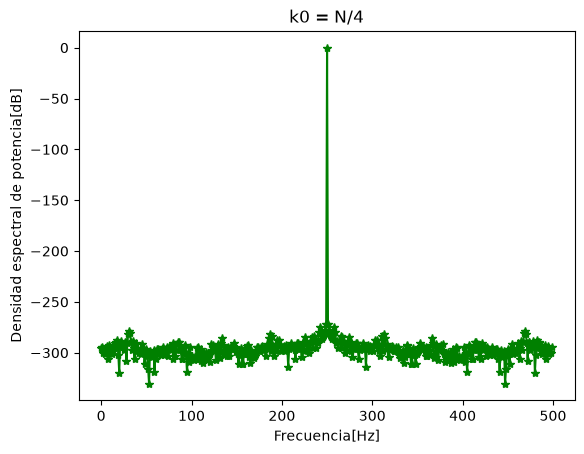

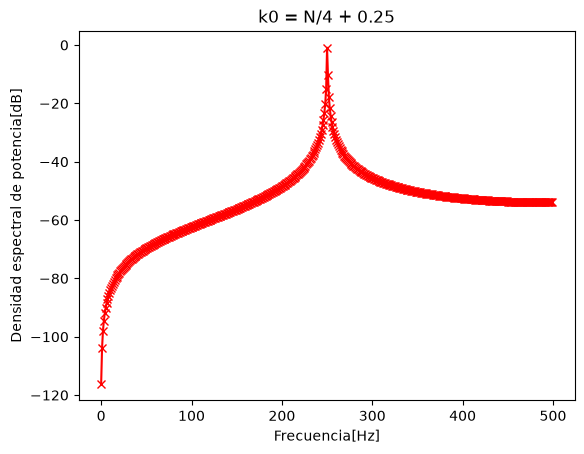

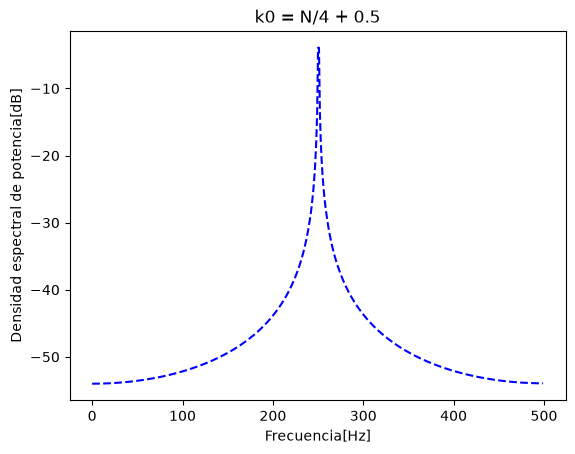

In [1]:
#importo modulos
import numpy as np
import matplotlib.pyplot as plt

N= 1000
fs= 1000
dc=0
ph=0
valores_k0 = [N/4, (N/4) +0.25, (N/4) +0.5]
k0 = np.array(valores_k0)
f0= k0* (fs/N)
P=1
vmax= np.sqrt(2*P)


#defino la funcion
def mi_funcion_sen( vmax, dc, frecuencia, ph, N, fs):
    
    nn= np.arange(0,N) / fs
    xx= dc + vmax*np.sin(2 * np.pi * frecuencia * nn + ph ) 

    return(nn, xx)

#PUNTO 1 INCISO A
ff_vec = np.fft.fftfreq(N,1/fs ) 
#A.1
nn, xx0 = mi_funcion_sen( vmax, dc, f0[0], ph, N, fs)
XX0 = np.fft.fft(xx0) 
XX0_mod = np.abs(XX0[:N//2]) * 2/N
P0 = XX0_mod**2 / 2
P0_db = 10*np.log10(P0)

#grafico
plt.figure()

plt.plot(ff_vec[:N//2], P0_db, 'g-*')
plt.title("k0 = N/4")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Densidad espectral de potencia[dB]")
plt.show()

#PUNTO 2 INCISO A
nn, xx1 = mi_funcion_sen( vmax, dc, f0[1], ph, N, fs)
XX1 = np.fft.fft(xx1) 
XX1_mod = np.abs(XX1[:N//2]) * 2/N
P1 = XX1_mod**2 / 2
P1_db = 10*np.log10(P1)
#grafico
plt.figure()

plt.plot(ff_vec[:N//2], P1_db,'r-x')
plt.title("k0 = N/4 + 0.25")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Densidad espectral de potencia[dB]")
plt.show()

#PUNTO 3 INCISO A
nn, xx2 = mi_funcion_sen( vmax, dc, f0[2], ph, N, fs)
XX2 = np.fft.fft(xx2) 
XX2_mod = np.abs(XX2[:N//2]) * 2/N
P2 = XX2_mod**2 / 2
P2_db = 10*np.log10(P2)
#grafico
plt.figure()

plt.plot(ff_vec[:N//2], P2_db, 'b--')
plt.title("k0 = N/4 + 0.5")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Densidad espectral de potencia[dB]")
plt.show()

Para $k_0 = N/4 = 250$, un valor entero, la frecuencia de la señal coincide exactamente con un bin de la FFT. Como la respuesta en frecuencia de la ventana rectangular implícita vale cero en todos los bines enteros excepto en el que corresponde a la frecuencia de la señal, el espectro obtenido muestra un pico angosto y limpio en 250 Hz, sin desparramo visible hacia los bines vecinos.

Para $k_0 = N/4 + 0.25 = 250.25$, la frecuencia real ya no coincide con un bin exacto, sino que cae entre el bin 250 y el 251. Como consecuencia, en esos bines la respuesta de la ventana ya no vale cero, y aparece el desparramo espectral, en vez de un pico limpio, se observa una caída hacia los bines vecinos.

Para $k_0 = N/4 + 0.5 = 250.5$, la frecuencia cae exactamente a mitad de camino entre dos bines, la peor situación posible en términos de desintonía. Esto produce el mayor desparramo espectral de los tres casos, y además el pico observado no alcanza los 0 dB sino que se ve atenuado, ya que la energía de la señal se reparte entre los dos bines vecinos sin que ninguno capture el valor máximo real.

### Inciso b)

La identidad de Parseval establece que la energía (o potencia) de una señal es la misma, ya sea que la calculemos en el dominio del tiempo o en el dominio de la frecuencia. Para señales discretas, se expresa como:

$$\sum_{n=0}^{N-1} x[n]^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

Usamos esto para verificar que, en los tres casos generados en el inciso a), la potencia calculada en el dominio del tiempo coincide con la potencia calculada a partir de la FFT.

In [2]:
# Potencia en el dominio del tiempo: promedio del cuadrado de todas las muestras de la señal
P_t0 = np.mean(xx0**2)

# Potencia en el dominio de la frecuencia:uso la FFT completa y aplico la normalizacion correspondiente
P_f0 = np.sum(np.abs(XX0)**2) / N**2

print("k0 = N/4")
print("Potencia en tiempo =", P_t0)
print("Potencia en frecuencia =", P_f0)

P_t1 = np.mean(xx1**2)
P_f1 = np.sum(np.abs(XX1)**2) / N**2
#grafico
print("k0 = N/4 + 0.25")
print("Potencia en tiempo =", P_t1)
print("Potencia en frecuencia =", P_f1)


P_t2 = np.mean(xx2**2)
P_f2 = np.sum(np.abs(XX2)**2) / N**2
#grafico
print("k0 = N/4 + 0.5")
print("Potencia en tiempo =", P_t2)
print("Potencia en frecuencia =", P_f2)

k0 = N/4
Potencia en tiempo = 1.0000000000000002
Potencia en frecuencia = 1.0000000000000002
k0 = N/4 + 0.25
Potencia en tiempo = 0.9989999999999998
Potencia en frecuencia = 0.9989999999999996
k0 = N/4 + 0.5
Potencia en tiempo = 1.0000000000000004
Potencia en frecuencia = 1.0000000000000007


En los tres casos, la potencia calculada en el dominio del tiempo coincide (con diferencias dmuy chicas, atribuibles al error de precisión numérica de punto flotante) con la potencia calculada en el dominio de la frecuencia, confirmando la identidad de Parseval.
Esto es importante porque, aunque las tres señales tienen exactamente la misma potencia normalizada a 1 y difieren solo en unos pocos Hz de frecuencia, sus espectros visualizados en el inciso a) son muy distintos entre si.
Esto se debe a que, según dónde caiga la frecuencia real respecto a bines de la FFT, la energía se distribuye de manera diferente entre los distintos bines.
Si la frecuencia coincide con un bin, toda la energía queda concentrada ahí
Si cae entre dos bines, se reparte entre varios.
Sin embargo, la identidad de Parseval confirma que la energía total de la señal es la misma en los tres casos, osea que lo que cambia no es cuánta energía hay, sino cómo se distribuye en frecuencia.

### Inciso c)

El zero padding consiste en agregar ceros al final de la señal antes de calcular la FFT. Esto no agrega información nueva sobre la señal real, pero sí aumenta la cantidad de puntos N que recibe la FFT, lo cual achica $\Delta_f = f_S/N$ y permite obtener más muestras del espectro.

En este inciso repetimos el experimento de los tres casos anteriores, agregando un vector de $9 \cdot N$ ceros al final de cada señal.

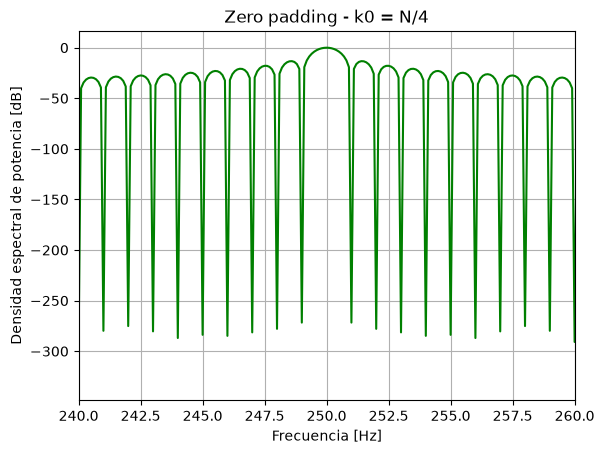

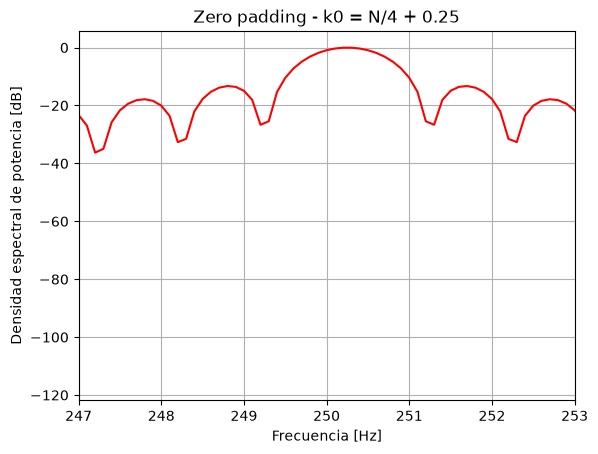

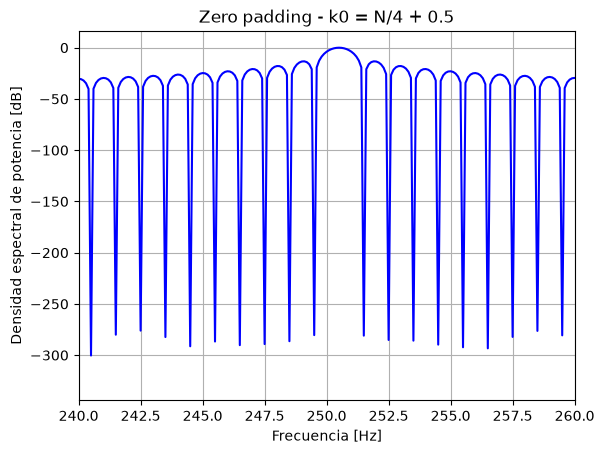

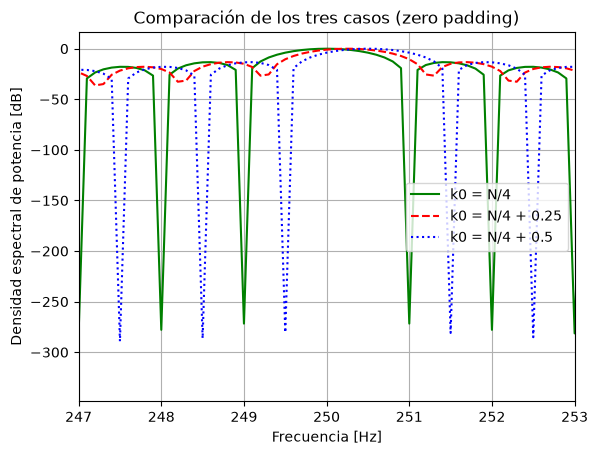

In [4]:
#INCISO C 

# agrego 9*N ceros al final de la señal original
xx0_zp = np.append(xx0, np.zeros(9*N))

# guardo la nueva longitud del vector
N_zp = len(xx0_zp)

# ahora calculo una FFT de 10000 puntos
XX0_zp = np.fft.fft(xx0_zp)

# creo un nuevo vector de frecuencias porque ahora la FFT tiene N_zp puntos y no N puntos
ff_vec_zp = np.fft.fftfreq(N_zp, 1/fs)

# tomo solamente la mitad positiva de la nueva FFT
XX0_zp_mod = np.abs(XX0_zp[:N_zp//2]) * 2/N

# calculo la potencia
P0_zp = XX0_zp_mod**2 / 2

# paso la potencia a decibeles
P0_db_zp = 10*np.log10(P0_zp)

# grafico
plt.figure()

plt.plot(ff_vec_zp[:N_zp//2], P0_db_zp, 'g-')
plt.title("Zero padding - k0 = N/4")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlim(240, 260) #para que se vea mejor
plt.grid()
plt.show()

xx1_zp = np.append(xx1, np.zeros(9*N))
N_zp = len(xx1_zp)
XX1_zp = np.fft.fft(xx1_zp)
ff_vec_zp = np.fft.fftfreq(N_zp, 1/fs)
XX1_zp_mod = np.abs(XX1_zp[:N_zp//2]) * 2/N

P1_zp = XX1_zp_mod**2 / 2
P1_db_zp = 10*np.log10(P1_zp)

# grafico
plt.figure()

plt.plot(ff_vec_zp[:N_zp//2], P1_db_zp, 'r-')
plt.title("Zero padding - k0 = N/4 + 0.25")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlim(247, 253) #para que se vea mejor
plt.grid()
plt.show()

xx2_zp = np.append(xx2, np.zeros(9*N))
N_zp = len(xx2_zp)
XX2_zp = np.fft.fft(xx2_zp)
ff_vec_zp = np.fft.fftfreq(N_zp, 1/fs)
XX2_zp_mod = np.abs(XX2_zp[:N_zp//2]) * 2/N

P2_zp = XX2_zp_mod**2 / 2
P2_db_zp = 10*np.log10(P2_zp)

# grafico
plt.figure()

plt.plot(ff_vec_zp[:N_zp//2], P2_db_zp, 'b-')
plt.title("Zero padding - k0 = N/4 + 0.5")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlim(240, 260) #para que se vea mejor
plt.grid()
plt.show()

# COMPARACION
plt.figure()
plt.plot(ff_vec_zp[:N_zp//2], P0_db_zp, 'g-', label='k0 = N/4')
plt.plot(ff_vec_zp[:N_zp//2], P1_db_zp, 'r--', label='k0 = N/4 + 0.25')
plt.plot(ff_vec_zp[:N_zp//2], P2_db_zp, 'b:', label='k0 = N/4 + 0.5')
plt.title("Comparación de los tres casos (zero padding)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlim(247, 253)
plt.legend()
plt.grid()
plt.show()

Al aplicar zero padding sobre el caso $k_0 = N/4$, el espectro dejó de verse como un pico limpio rodeado de un piso plano de ruido, y mostró la forma completa de la respuesta en frecuencia de la ventana rectangular, un lóbulo principal y una serie de lóbulos laterales con ceros bien marcados entre ellos. Esto demuestra que el desparramo espectral siempre estuvo presente matemáticamente, incluso en el caso "sin desparramo" del inciso a) lo que ocurría sin zero padding es que la FFT original solo evaluaba esa forma continua justo en sus ceros, ocultando su verdadera estructura.

Para $k_0 = N/4 + 0.25$, el zero padding permitió visualizar con mucho más detalle la asimetría del espectro, los lóbulos de un lado del pico quedan más próximos entre sí que los del otro lado, reflejando que la frecuencia real está más cerca de un bin que del otro.

Para $k_0 = N/4 + 0.5$, en cambio, el zero padding mostró un espectro simétrico pero con una meseta plana en el pico, en vez de un máximo en punta, consistente con que la frecuencia cae exactamente a mitad de camino entre dos bines, y confirmando que el pico se queda un poco por debajo de 0 dB.

En los tres casos, es importante notar que el zero padding no modificó el ancho real del lóbulo principal (ya que depende únicamente de la cantidad de muestras reales de la señal, $N=1000$, y no de los ceros agregados), sino que permitió interpolar y visualizar con mayor detalle una forma espectral que ya estaba determinada de antemano por los datos originales. Es decir, el zero padding mejora la resolución de visualización del espectro, pero no la capacidad de distinguir dos frecuencias muy cercanas entre sí.

### Conclusión

Se pudo observar que el desparramo espectral es un efecto que siempre está presente cuando trabajamos con una señal finita, aunque no siempre se vea reflejado en la FFT, si la frecuencia de la señal coincide exactamente con un bin, el efecto queda "escondido" porque la FFT muestrea justo en los ceros de la respuesta de la ventana. Si la frecuencia cae entre dos bines, el efecto se hace visible, y es máximo cuando cae justo a mitad de camino entre dos bines.

También se verificó, mediante la identidad de Parseval, que aunque la forma del espectro cambie mucho entre los tres casos, la energía total de la señal se mantiene siempre igual ya que lo que cambia es solamente cómo se distribuye esa energía entre los distintos bines.

Por último, vimos que el zero padding es una herramienta útil para visualizar con más detalle la forma del espectro ya que revela los lóbulos que antes quedaban ocultos entre los puntos de la FFT, pero no mejora el ancho del lóbulo principal, que determina si podemos distinguir dos frecuencias cercanas, depende únicamente de la cantidad de muestras reales de la señal, y no cambia por agregar ceros.